In [ ]:
outliers are redundant observations. bcz they spoil the performance of the model.
Defination : points which are extremly far from the normal observations.

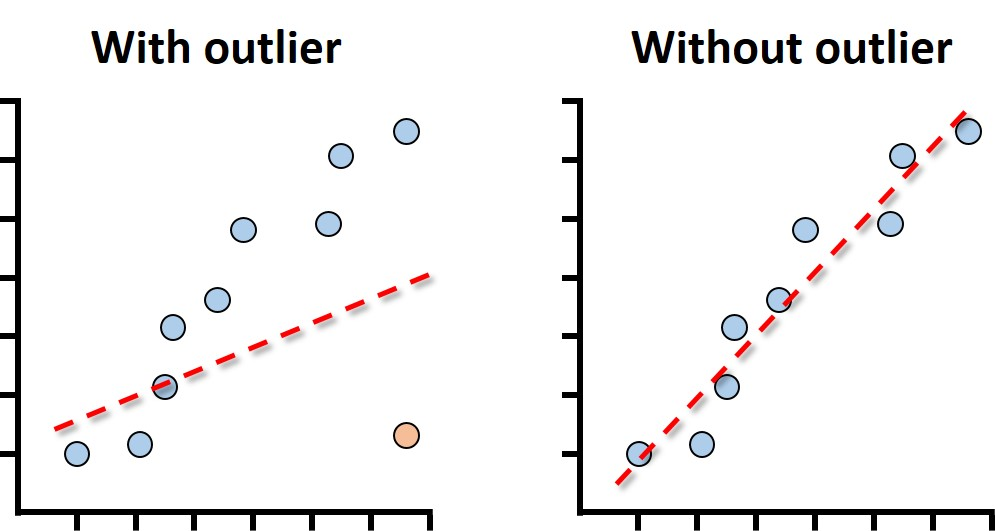

In [ ]:
Treating of outliers:
    1. dropping
    2. winitializing (replacing the outliers with statistical computations(mean,median,mode etc..))
    3. Thresold split
    4. Normalizing
    5. Tranformation:
        1. log transform
        2. Noramlization (0-1)
        3. standardization (-1 to 1)
        4. box-cox transform
        5. sqrt transform
        6. cbrt transform
        7. reciprocal transform

# Detecting outliers

## check if the data is noramlly distributed

In [1]:
import numpy as np

In [27]:
array = np.random.randint(10,100,size = 20)
array

array([54, 59, 62, 71, 91, 48, 27, 17, 52, 61, 31, 77, 20, 72, 18, 96, 69,
       40, 27, 53])

<AxesSubplot:ylabel='Density'>

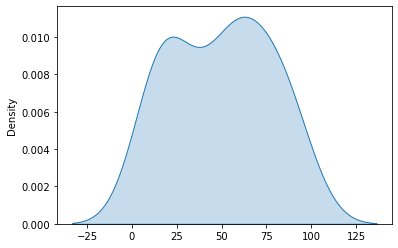

In [3]:
import seaborn as sns
sns.kdeplot(array,fill=True)

In [19]:
array2 = array.copy()
array2[10]=200
array2[12]=250
array2[5]=-200
array2

array([  86,   90,   58,   12,   49, -200,   77,   15,   91,   29,  200,
         14,  250,   76,   50,   65,   18,   56,   36,   58])

<AxesSubplot:ylabel='Density'>

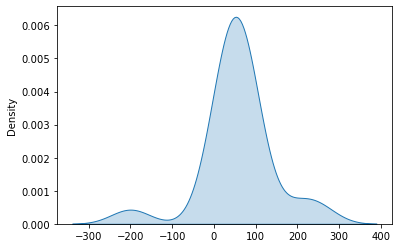

In [20]:
import seaborn as sns
sns.kdeplot(array2,fill=True)

## z-score Normalization

In [22]:
mean = np.mean(array2)
std = np.std(array2)
print('mean is ',mean, 'std is ',std)

outliers_list=[]
thresold = 1.5

for x_val in array2:
    z_score = (x_val-mean)/std
    z_score = np.abs(z_score)
    print(z_score)
    
    if z_score >= thresold:
        outliers_list.append(x_val)
        
outliers_list

mean is  56.5 std is  82.5084844122106
0.3575389877799553
0.40601885052977976
0.018179948531184167
0.5393384730917969
0.09089974265592084
3.1087711988324926
0.2484592965928503
0.5029785760294286
0.41813881621723586
0.3332990564050431
1.739215076149952
0.5150985417168847
2.3452133605227576
0.2363393309053942
0.07877977696846472
0.10301970834337695
0.46661867896706033
0.0060599828437280555
0.2484592965928503
0.018179948531184167


[-200, 200, 250]

In [16]:
array2[np.where(array2>150)]

array([200, 250])

In [25]:
np.where(array2<=min(outliers_list),np.mean(array2),array2)

array([ 86. ,  90. ,  58. ,  12. ,  49. ,  56.5,  77. ,  15. ,  91. ,
        29. , 200. ,  14. , 250. ,  76. ,  50. ,  65. ,  18. ,  56. ,
        36. ,  58. ])

# Using IQR

In [28]:
array

array([54, 59, 62, 71, 91, 48, 27, 17, 52, 61, 31, 77, 20, 72, 18, 96, 69,
       40, 27, 53])

In [29]:
q1 = np.quantile(array,0.25)
q1

30.0

In [30]:
q1 = np.quantile(array,0.75)
q1

69.5

In [31]:
q1 = np.quantile(array,0.5)
q1

53.5

In [33]:
import pandas as pd
pd.Series(array).describe()

count    20.000000
mean     52.250000
std      23.644016
min      17.000000
25%      30.000000
50%      53.500000
75%      69.500000
max      96.000000
dtype: float64

In [38]:
df = pd.read_csv('titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [42]:
df.dropna(subset=['Age'],inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 714 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Name         714 non-null    object 
 4   Gender       714 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        714 non-null    int64  
 7   Parch        714 non-null    int64  
 8   Ticket       714 non-null    object 
 9   Fare         714 non-null    float64
 10  Cabin        185 non-null    object 
 11  Embarked     712 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 72.5+ KB


In [47]:
df.Age.describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [49]:
Q1 = df.Age.describe()[4]
Q2 = df.Age.describe()[5]
Q3 = df.Age.describe()[6]

print(Q1,Q2,Q3)

20.125 28.0 38.0


In [50]:
Q1 = df.Age.quantile(0.25)
Q2 = df.Age.quantile(0.5)
Q3 = df.Age.quantile(0.75)

print(Q1,Q2,Q3)

20.125 28.0 38.0


In [51]:
IQR = Q3-Q1
print(IQR)

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print(lower_bound,upper_bound)

17.875
-6.6875 64.8125


In [54]:
df.loc[(df.Age>upper_bound) | (df.Age<lower_bound)]['Age']

33     66.0
54     65.0
96     71.0
116    70.5
280    65.0
456    65.0
493    71.0
630    80.0
672    70.0
745    70.0
851    74.0
Name: Age, dtype: float64

In [58]:
outlier_indices = df.loc[(df.Age>upper_bound) | (df.Age<lower_bound)].index
outlier_indices

Int64Index([33, 54, 96, 116, 280, 456, 493, 630, 672, 745, 851], dtype='int64')

## detecting outliers using boxplot

C:\Users\Pratik\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Age'>

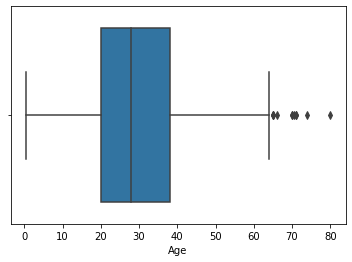

In [59]:
sns.boxplot(df.Age)

<AxesSubplot:xlabel='Age', ylabel='Density'>

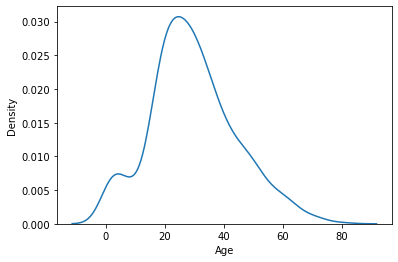

In [62]:
sns.kdeplot(df.Age)

## dropping the outliers

In [63]:
df.loc[~((df.Age>upper_bound) | (df.Age<lower_bound))]

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Imputing for Outliers

In [65]:
median = df.Age.median()
median

28.0

In [77]:
mean_age = df.loc[(df.Age<upper_bound)&(df.Age>10)]['Age'].mean()
print('mean age prior to removing outliers is ',mean_age)

df.Age.loc[df.Age>upper_bound] = mean_age
print('mean age after imputing for outliers is ',df.Age.mean())

mean age prior to removing outliers is  31.496153846153845
mean age after imputing for outliers is  29.055560224089632


C:\Users\Pratik\anaconda3\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


In [78]:
df.Age.loc[df.Age>upper_bound]

Series([], Name: Age, dtype: float64)

<AxesSubplot:>

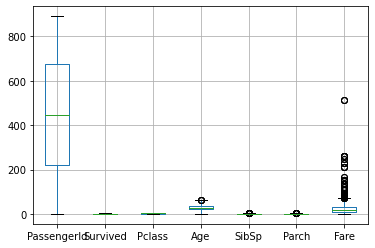

In [79]:
df.boxplot()

<AxesSubplot:>

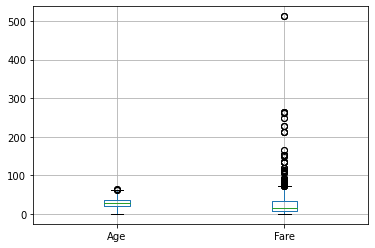

In [80]:
df.boxplot(['Age','Fare'])